<a href="https://colab.research.google.com/github/clobos/Python_Tatiana_Ecologia_Aplicada/blob/main/codigo_unico_2010_2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [139]:
#!pip install pmdarima
#!pip install prophet
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pmdarima as pm
from prophet import Prophet # Changed from fbprophet to prophet

In [140]:
# Load the Excel file into a DataFrame named df
df = pd.read_excel('/content/df_curto_2010.xlsx')

In [141]:
df

,Ano,Estado,Municipio,RDO_RPU
0,2010,AC,Acrelândia,NaN
1,2010,AC,Assis Brasil,NaN
2,2010,AC,Brasiléia,NaN
3,2010,AC,Bujari,NaN
4,2010,AC,Capixaba,NaN
...,...,...,...,...
63617,2022,TO,Tocantinópolis,18948.9
63618,2022,TO,Tupirama,280.0
63619,2022,TO,Tupiratins,100.0
63620,2022,TO,Wanderlândia,2444.0


In [142]:
municipios_por_estado = df.groupby('Estado')['Municipio'].nunique().reset_index()
municipios_por_estado.columns = ['Estado', 'Numero de Municipios']

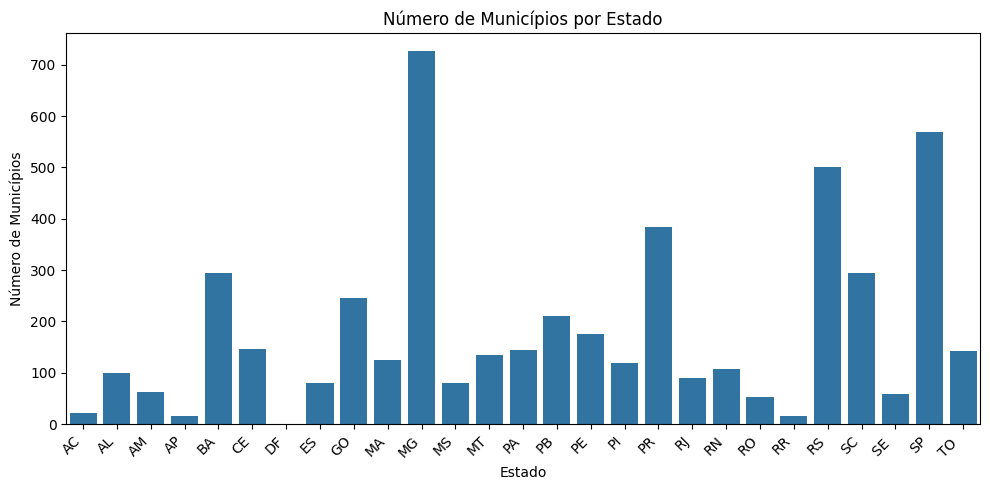

In [143]:
# Grafico de barras do municipios_por_estado
plt.figure(figsize=(10, 5))
sns.barplot(x='Estado', y='Numero de Municipios', data=municipios_por_estado)
plt.title('Número de Municípios por Estado')
plt.xlabel('Estado')
plt.ylabel('Número de Municípios')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [144]:
missing_data_summary = df.groupby(['Estado', 'Municipio'])['RDO_RPU'].agg(
    total_rows='size',
    missing_count=lambda x: x.isnull().sum(),
    complete_count=lambda x: x.count()
).reset_index()

missing_data_summary

,Estado,Municipio,total_rows,missing_count,complete_count
0,AC,Acrelândia,13,11,2
1,AC,Assis Brasil,13,7,6
2,AC,Brasiléia,13,2,11
3,AC,Bujari,13,3,10
4,AC,Capixaba,13,6,7
...,...,...,...,...,...
4889,TO,Tocantínia,13,2,11
4890,TO,Tupirama,13,3,10
4891,TO,Tupiratins,13,2,11
4892,TO,Wanderlândia,13,7,6


In [153]:
Estado = 'AC'
Numero_Dados_Completos = 13

subconjunto = missing_data_summary[
   (missing_data_summary['Estado'] == Estado) &
    (missing_data_summary['complete_count'] >= Numero_Dados_Completos)
]
display(subconjunto[['Estado', 'Municipio', 'complete_count']])

,Estado,Municipio,complete_count
15,AC,Rio Branco,13
16,AC,Rodrigues Alves,13


In [148]:
# # 1. Filtrar o DataFrame original 'df' com base nos pares (Estado, Municipio) presentes em 'subconjunto'
# # Criar um MultiIndex a partir de subconjunto para uma busca eficiente
# subconjunto_index = subconjunto.set_index(['Estado', 'Municipio']).index

# # Filtrar df
# df_for_plot = df[
#     df.set_index(['Estado', 'Municipio']).index.isin(subconjunto_index)
# ].copy()

# # Criar um identificador combinado para cada série para melhor representação na legenda
# df_for_plot['Municipio_Estado'] = df_for_plot['Municipio'] + ' (' + df_for_plot['Estado'] + ')'

# # Garantir que 'Ano' seja tratado como numérico para plotagem
# df_for_plot['Ano'] = pd.to_numeric(df_for_plot['Ano'])

# # 2. Criar o gráfico
# plt.figure(figsize=(14, 8)) # Aumentar o tamanho da figura para acomodar mais séries
# sns.lineplot(data=df_for_plot,
#              x='Ano',
#              y='RDO_RPU',
#              hue='Municipio_Estado', # Usar o identificador combinado para a cor
#              marker='o')
# plt.title('Série Temporal: RDO_RPU para Municípios com Dados Completos', fontsize=16)
# plt.xlabel('Ano', fontsize=12)
# plt.ylabel('RDO_RPU', fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.6)
# # Ajustar o posicionamento da legenda para evitar sobreposição com o gráfico
# plt.legend(title='Município (Estado)', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
# plt.xticks(rotation=45)
# plt.tight_layout() # Ajustar automaticamente os parâmetros do subplot para um layout apertado
# plt.show()

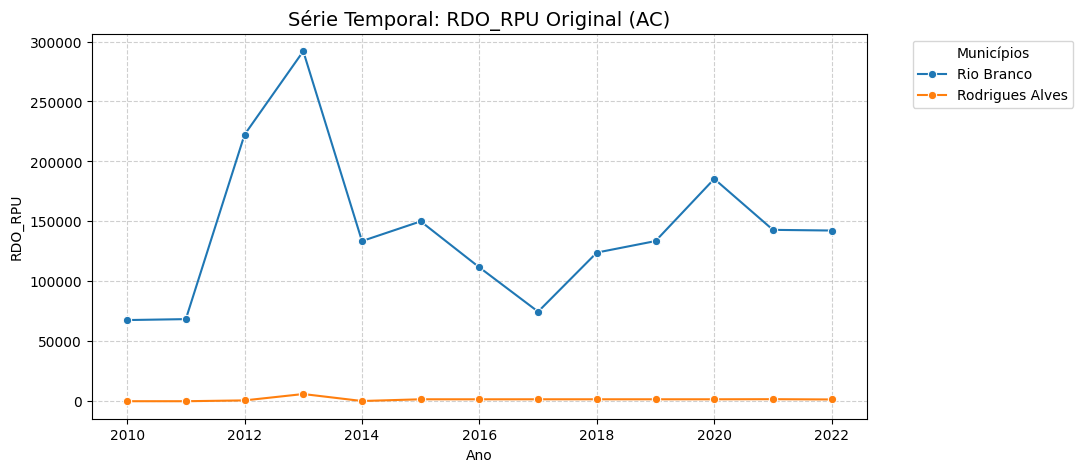

In [158]:
# --- 1. FILTRAGEM E PREPARAÇÃO ---
# Identifica os municípios do AC que atendem ao critério de dados completos
municipios_ac_para_plotar = missing_data_summary[
    (missing_data_summary['Estado'] == Estado) &
    (missing_data_summary['complete_count'] >= Numero_Dados_Completos)
]['Municipio'].unique()

# Filtra o DataFrame original 'df' apenas para esses municípios
df_plot = df[
    (df['Estado'] == Estado) &
    (df['Municipio'].isin(municipios_ac_para_plotar))
].copy()

# --- 2. PADRONIZAÇÃO (Z-Score) ---
# Criamos a coluna padronizada aplicando o scaler individualmente por município
scaler = StandardScaler()
df_plot['RDO_RPU_Standardized'] = df_plot.groupby('Municipio')['RDO_RPU'].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten() if x.notnull().any() else x
)

# --- 3. VISUALIZAÇÃO (Grade 2x1 para comparar Bruto vs Padronizado) ---
# Embora você tenha pedido 1x1, geralmente é útil ver ambos.
# Se quiser apenas um, basta escolher um dos blocos de 'sns.lineplot' abaixo.
plt.figure(figsize=(10, 5)) # Tamanho ajustado para um único gráfico

# Gráfico 1: Dados Originais (RDO_RPU)
sns.lineplot(data=df_plot,
             x='Ano',
             y='RDO_RPU',
             hue='Municipio',
             marker='o')
plt.title(f'Série Temporal: RDO_RPU Original ({Estado})', fontsize=14)
plt.ylabel('RDO_RPU')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Municípios', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

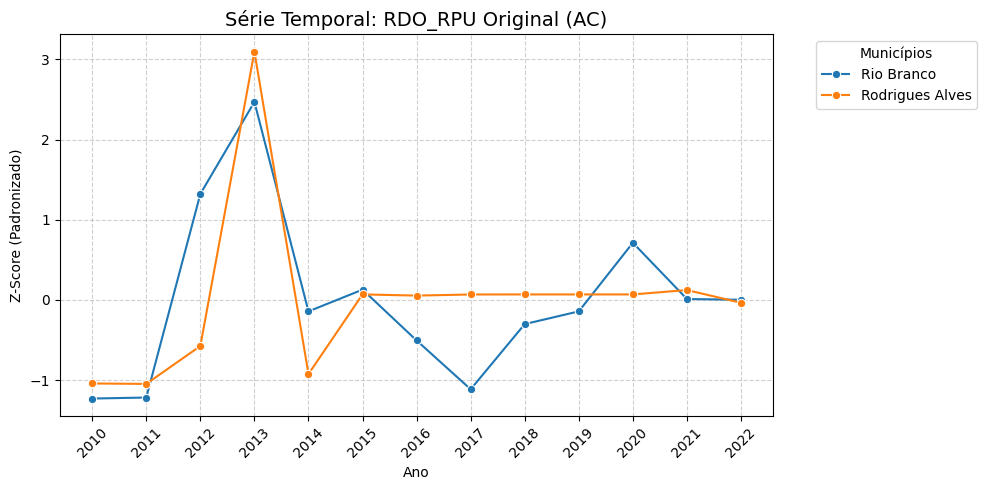

In [159]:
# Gráfico 2: Dados Padronizados (RDO_RPU_Standardized)
fig, ax2 = plt.subplots(figsize=(10, 5)) # Define fig and ax2 for the plot
sns.lineplot(data=df_plot, x='Ano', y='RDO_RPU_Standardized', hue='Municipio', marker='o', ax=ax2)
ax2.set_title(f'Série Temporal: RDO_RPU Original ({Estado})', fontsize=14)
ax2.set_ylabel('Z-Score (Padronizado)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(title='Municípios', bbox_to_anchor=(1.05, 1), loc='upper left')

ax2.set_xlabel('Ano') # Use ax2 for xlabel
ax2.set_xticks(df_plot['Ano'].unique()) # Set unique years as x-ticks
ax2.tick_params(axis='x', rotation=45) # Rotate x-axis labels
plt.tight_layout()
plt.show()

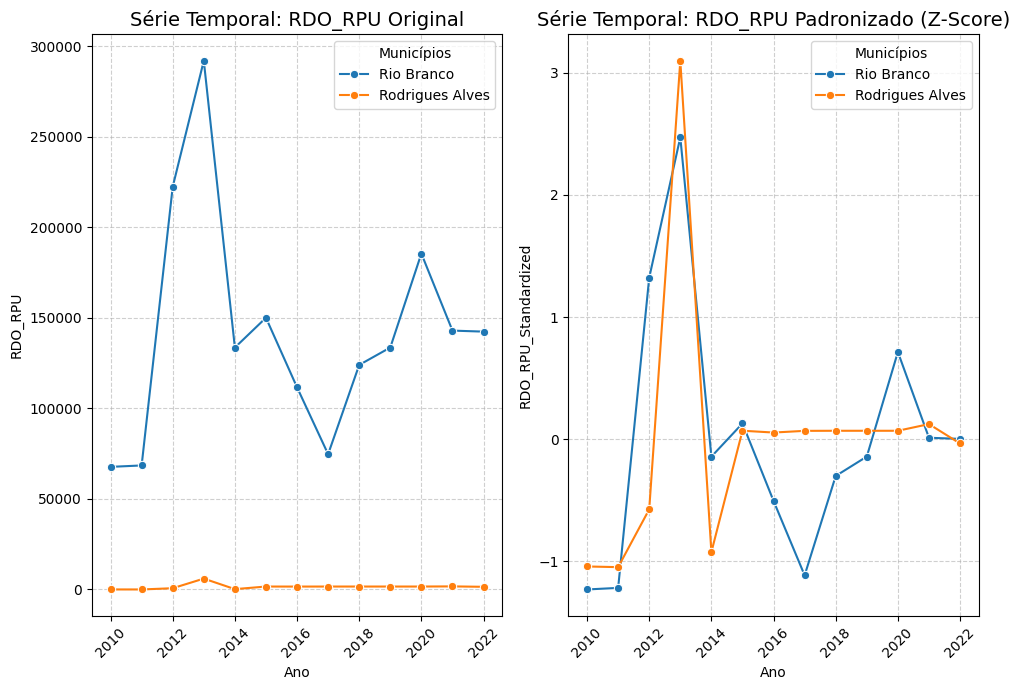

In [161]:
# --- 1. FILTRAGEM E PREPARAÇÃO ---
municipios_ac_para_plotar = missing_data_summary[
    (missing_data_summary['Estado'] == Estado) &
    (missing_data_summary['complete_count'] >= Numero_Dados_Completos)
]['Municipio'].unique()

df_plot = df[
    (df['Estado'] == Estado) &
    (df['Municipio'].isin(municipios_ac_para_plotar))
].copy()

# --- 2. PADRONIZAÇÃO ---
scaler = StandardScaler()
df_plot['RDO_RPU_Standardized'] = df_plot.groupby('Municipio')['RDO_RPU'].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten() if x.notnull().any() else x
)

# --- 3. VISUALIZAÇÃO (1 LINHA x 2 COLUNAS) ---
# figsize ajustado para ser mais largo (20) do que alto (7)
fig, axes = plt.subplots(1, 2, figsize=(10, 7))

# Figura 1 (Esquerda): Dados Originais
sns.lineplot(data=df_plot, x='Ano', y='RDO_RPU', hue='Municipio', marker='o', ax=axes[0])
axes[0].set_title('Série Temporal: RDO_RPU Original', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(title='Municípios')

# Figura 2 (Direita): Dados Padronizados
sns.lineplot(data=df_plot, x='Ano', y='RDO_RPU_Standardized', hue='Municipio', marker='o', ax=axes[1])
axes[1].set_title('Série Temporal: RDO_RPU Padronizado (Z-Score)', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(title='Municípios')

# Ajustes finais de layout
for ax in axes:
    ax.set_xlabel('Ano')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

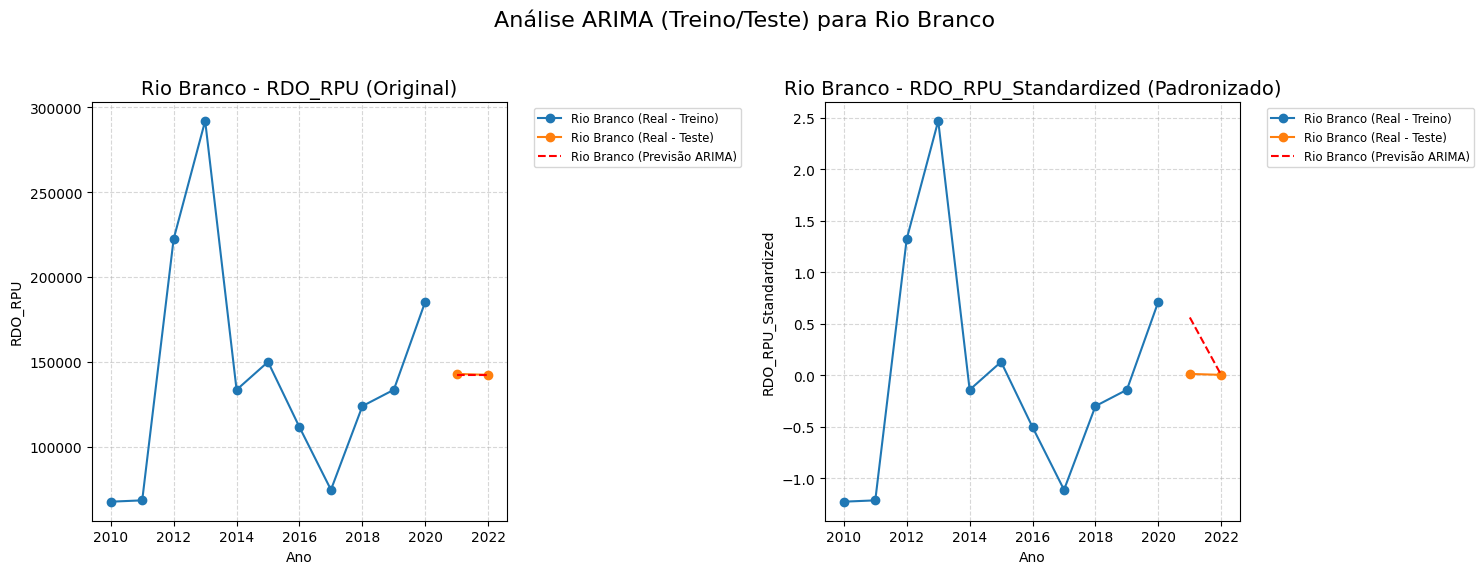

SARIMAX Results for Rio Branco (RDO_RPU Padronizado - Treino):
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   11
Model:               SARIMAX(0, 0, 1)   Log Likelihood                 -15.232
Date:                Wed, 22 Apr 2026   AIC                             34.463
Time:                        20:36:24   BIC                             35.259
Sample:                    01-01-2010   HQIC                            33.962
                         - 01-01-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.7362      0.340      2.167      0.030       0.070       1.402
sigma2         0.8699      0.585      1.488      0.137      -0.276  

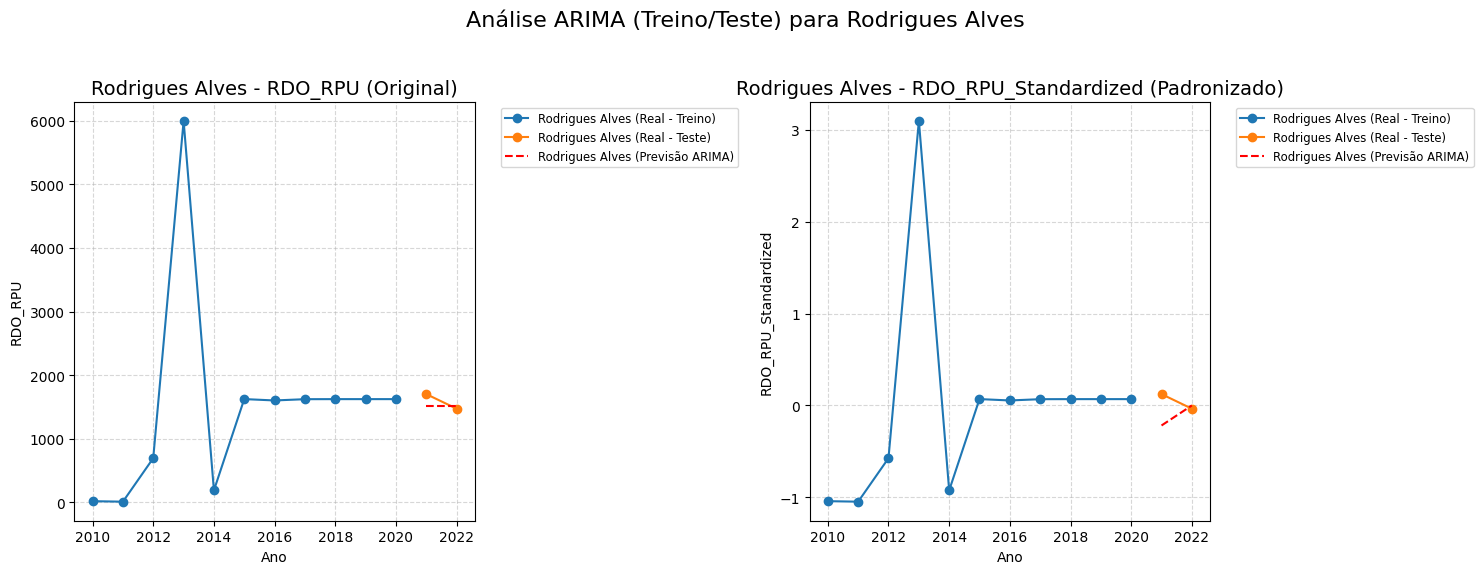

SARIMAX Results for Rodrigues Alves (RDO_RPU Padronizado - Treino):
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   11
Model:               SARIMAX(0, 0, 1)   Log Likelihood                 -15.454
Date:                Wed, 22 Apr 2026   AIC                             34.908
Time:                        20:36:27   BIC                             35.704
Sample:                    01-01-2010   HQIC                            34.406
                         - 01-01-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7364      0.440     -1.672      0.094      -1.599       0.127
sigma2         0.9057      0.679      1.333      0.182      -0.

In [162]:
# --- 1. Preparação dos Dados ---
# Garantir que os dados estejam ordenados por ano para a série temporal
df_plot = df_plot.sort_values(['Municipio', 'Ano'])

# --- 2. Função auxiliar para ajustar e plotar ARIMA para uma única série ---
def plot_arima_for_one_series(serie, ax, serie_name, municipio_name, is_standardized=False):
    model = None

    # Calculate the split point for 90% train and 10% test
    n_total_observations = len(serie)
    n_train_observations = int(n_total_observations * 0.9)

    # Ensure there's at least 1 observation for test if possible
    if n_total_observations > 0 and n_train_observations == n_total_observations:
        n_train_observations = n_total_observations - 1
        if n_train_observations < 0: n_train_observations = 0 # Avoid negative in case of 0 or 1 total observation

    if n_train_observations > 0 and (n_total_observations - n_train_observations) >= 1: # Ensure at least one training and one test observation
        train_data = serie.iloc[:n_train_observations]
        test_data = serie.iloc[n_train_observations:]

        # Ajuste automático do modelo ARIMA (p, d, q) nos dados de treinamento
        model = pm.auto_arima(train_data, seasonal=False, error_action='ignore', suppress_warnings=True)

        # Gerar a previsão para o período de teste
        forecast = model.predict(n_periods=len(test_data))
        forecast_series = pd.Series(forecast, index=test_data.index) # Align forecast with test data index

        # Plotar a linha de treino original
        ax.plot(train_data.index, train_data.values, marker='o', label=f'{municipio_name} (Real - Treino)')
        # Plotar a linha de teste original
        ax.plot(test_data.index, test_data.values, marker='o', label=f'{municipio_name} (Real - Teste)')
        # Plotar a previsão
        ax.plot(forecast_series.index, forecast_series.values, linestyle='--', color='red', label=f'{municipio_name} (Previsão ARIMA)')

    else:
        ax.text(0.5, 0.5, 'Dados insuficientes para dividir em treino/teste com a proporção de 90/10 e ajustar o modelo ARIMA', transform=ax.transAxes,
                horizontalalignment='center', verticalalignment='center', fontsize=12, color='red')
        # If not enough data for train/test split, still plot the full series if it has some data for context
        if len(serie) > 0:
            ax.plot(serie.index, serie.values, marker='o', label=f'{municipio_name} (Real - Completo)')

    ax.set_title(f'{municipio_name} - {serie_name} ({"Padronizado" if is_standardized else "Original"})', fontsize=14)
    ax.set_xlabel('Ano')
    ax.set_ylabel(serie_name)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    return model

# --- 3. Execução para cada município separadamente ---
for municipio_name in df_plot['Municipio'].unique():
    municipio_data = df_plot[df_plot['Municipio'] == municipio_name].copy() # Make a copy to avoid SettingWithCopyWarning

    # Convert 'Ano' to DatetimeIndex for both series to avoid statsmodels warnings
    municipio_data['Ano'] = pd.to_datetime(municipio_data['Ano'], format='%Y')

    # Criar uma nova figura com dois subplots para cada município
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Análise ARIMA (Treino/Teste) para {municipio_name}', fontsize=16)

    # Plotar ARIMA para RDO_RPU Original
    serie_original = municipio_data.set_index('Ano')['RDO_RPU'].dropna()
    plot_arima_for_one_series(serie_original, axes[0], 'RDO_RPU', municipio_name, is_standardized=False)

    # Plotar ARIMA para RDO_RPU Padronizado
    serie_standardized = municipio_data.set_index('Ano')['RDO_RPU_Standardized'].dropna()
    last_standardized_model_municipio = plot_arima_for_one_series(serie_standardized, axes[1], 'RDO_RPU_Standardized', municipio_name, is_standardized=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

    # --- 4. Exemplo de Sumário de um Modelo (Opcional) ---
    # Exibe os parâmetros encontrados para o modelo padronizado do município atual
    if last_standardized_model_municipio is not None:
        print(f"SARIMAX Results for {municipio_name} (RDO_RPU Padronizado - Treino):")
        print(last_standardized_model_municipio.summary())
    else:
        print(f"No model was fitted for {municipio_name} (RDO_RPU Padronizado) to display summary (insufficient data).")
    print("-" * 80) # Separator for better readability

INFO:prophet:n_changepoints greater than number of observations. Using 7.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  dates = pd.date_range(
INFO:prophet:n_changepoints greater than number of observations. Using 7.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  dates = pd.date_range(


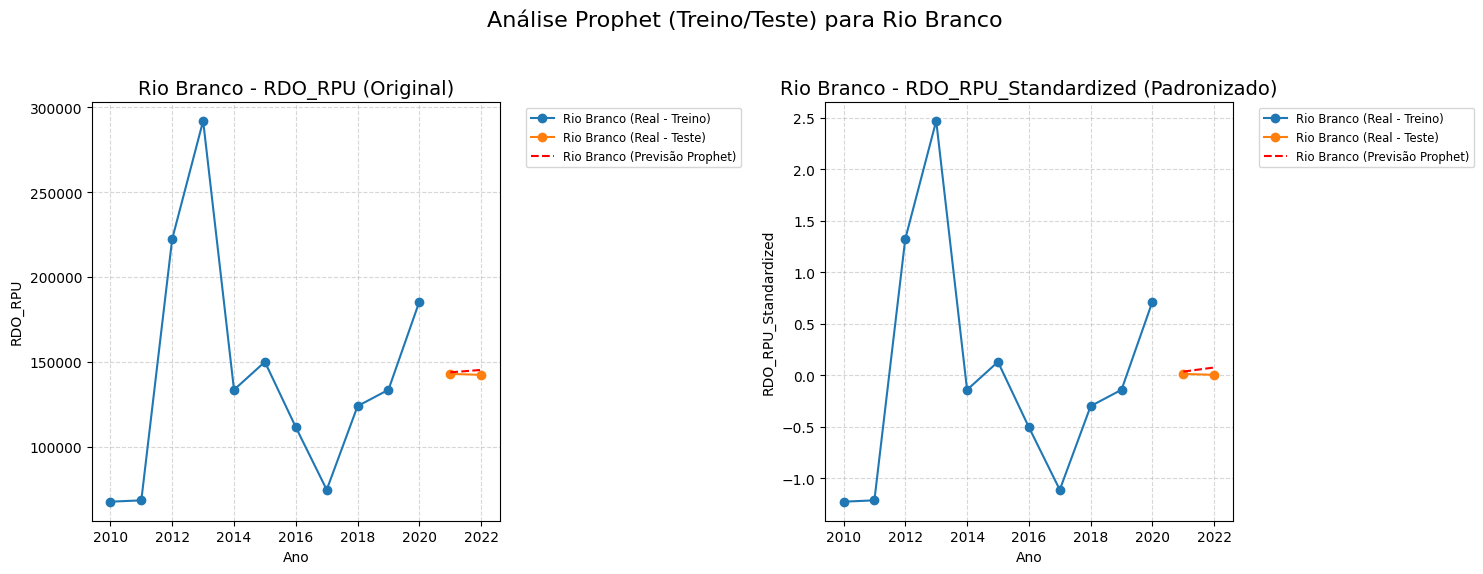

INFO:prophet:n_changepoints greater than number of observations. Using 7.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  dates = pd.date_range(
INFO:prophet:n_changepoints greater than number of observations. Using 7.


--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  dates = pd.date_range(


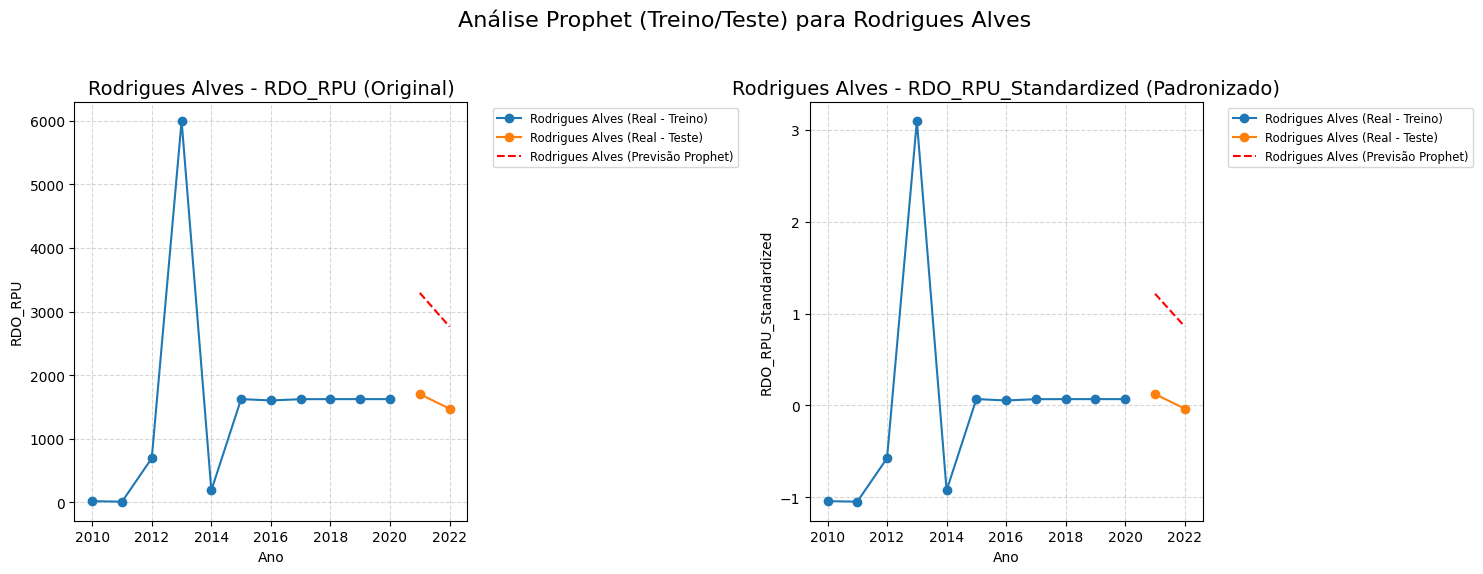

--------------------------------------------------------------------------------


In [163]:
# --- 1. Preparação dos Dados ---
# Garantir que os dados estejam ordenados por ano para a série temporal
df_plot = df_plot.sort_values(['Municipio', 'Ano'])

# --- 2. Função auxiliar para ajustar e plotar Prophet para uma única série ---
def plot_prophet_for_one_series(serie, ax, serie_name, municipio_name, is_standardized=False):
    # Prepare data for Prophet: needs 'ds' (date) and 'y' (value)
    df_prophet = pd.DataFrame({
        'ds': serie.index,
        'y': serie.values
    }).reset_index(drop=True)

    n_total_observations = len(df_prophet)
    n_train_observations = int(n_total_observations * 0.9)

    # Ensure there's at least 1 observation for test if possible
    if n_total_observations > 0 and n_train_observations == n_total_observations:
        n_train_observations = n_total_observations - 1
        if n_train_observations < 0: n_train_observations = 0 # Avoid negative in case of 0 or 1 total observation

    if n_train_observations > 0 and (n_total_observations - n_train_observations) >= 1: # Ensure at least one training and one test observation
        train_data = df_prophet.iloc[:n_train_observations]
        test_data = df_prophet.iloc[n_train_observations:]

        # Initialize and fit the Prophet model
        model = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False) # Assuming yearly data, adjust as needed
        model.fit(train_data)

        # Create a DataFrame for future predictions
        future = model.make_future_dataframe(periods=len(test_data), freq='AS') # 'AS' for Annual Start frequency

        # Generate predictions
        forecast = model.predict(future)

        # Plotting
        ax.plot(train_data['ds'], train_data['y'], marker='o', label=f'{municipio_name} (Real - Treino)')
        ax.plot(test_data['ds'], test_data['y'], marker='o', label=f'{municipio_name} (Real - Teste)')
        ax.plot(forecast['ds'].iloc[n_train_observations:], forecast['yhat'].iloc[n_train_observations:], linestyle='--', color='red', label=f'{municipio_name} (Previsão Prophet)')

    else:
        ax.text(0.5, 0.5, 'Dados insuficientes para dividir em treino/teste com a proporção de 90/10 e ajustar o modelo Prophet', transform=ax.transAxes,
                horizontalalignment='center', verticalalignment='center', fontsize=12, color='red')
        if len(df_prophet) > 0:
            ax.plot(df_prophet['ds'], df_prophet['y'], marker='o', label=f'{municipio_name} (Real - Completo)')

    ax.set_title(f'{municipio_name} - {serie_name} ({"Padronizado" if is_standardized else "Original"})', fontsize=14)
    ax.set_xlabel('Ano')
    ax.set_ylabel(serie_name)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# --- 3. Execução para cada município separadamente ---
for municipio_name in df_plot['Municipio'].unique():
    municipio_data = df_plot[df_plot['Municipio'] == municipio_name].copy() # Make a copy to avoid SettingWithCopyWarning

    # Convert 'Ano' to DatetimeIndex for both series
    municipio_data['Ano'] = pd.to_datetime(municipio_data['Ano'], format='%Y')

    # Criar uma nova figura com dois subplots para cada município
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Análise Prophet (Treino/Teste) para {municipio_name}', fontsize=16)

    # Plotar Prophet para RDO_RPU Original
    serie_original = municipio_data.set_index('Ano')['RDO_RPU'].dropna()
    plot_prophet_for_one_series(serie_original, axes[0], 'RDO_RPU', municipio_name, is_standardized=False)

    # Plotar Prophet para RDO_RPU Padronizado
    serie_standardized = municipio_data.set_index('Ano')['RDO_RPU_Standardized'].dropna()
    plot_prophet_for_one_series(serie_standardized, axes[1], 'RDO_RPU_Standardized', municipio_name, is_standardized=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

    print("-" * 80) # Separator for better readability
